# Crash!💥 Boom!💥 Bang! 💥🚗🚙💥🚗
**A SQL based exploratory data analysis of traffic accidents in Okinawa, Japan**
  
---   
# <span style="color:#0279f0;">Part 4: Temporal Analysis</span>
---
We now know where the accident black spots are. Also knowing when accidents are most dangerous will guide us in deploying the right resources like emergency response and traffic enforcement resources as well as targeted public awareness campaigns to make the roads safer.  

To achieve this, we will analyse:
1. **Day/Night and Dawn/Dusk Periods** - Do lighting conditons affect accident severity?
2. **Holiday Impact** - While we've already seen that most accidents happen during the weekday rush hours, we should also examine holiday periods since the driver profiles and traffic patterns may be different. Would holiday accidents prove more deadly?
3. **Fatality Patterns** - And putting it all together, when would be the deadliest time to be driving in Okinawa?  

**Tools used in this notebook:**
- Pandas – for loading the CSV, quick checks and basic data manipulation.
- DuckDB – for all aggregation queries
- Matplotlib & Seaborn - for data visualisation

##### 👩🏻‍💻  *<span style="color:#0279f0">Loading data to begin...</span>*

In [16]:
import sys
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from sql.notebook_setup import *

# Load data with pandas
accidents_df = load_data(FILTERED_DATA_PATH)
municipal_df = load_data(MUNICIPAL_DATA_PATH)

# Connect to DuckDB
conn = create_connection()
# Register dataframes with DuckDB
register_table(conn, "accidents", accidents_df)

#Verify dataset is loaded
print_summary(accidents_df,"`Accidents` Table",10)



✅ `Accidents` Table: 2,749 records
----------------------------------------
✅ Showing 10 of 68 columns:
 1. data_category
 2. prefecture_code
 3. police_station_code
 4. report_id
 5. accident_details_code
 6. fatalities
 7. injured_persons
 8. route_code
 9. location_code
10. municipality_code
... 58 additional columns


..........  

### **4.1 Day/Night and Dawn/Dusk Periods**  
How do lighting conditions affect accident severity?

##### 👩🏻‍💻  *<span style="color:#0279f0">SQL: Analysing Municipality Accident Counts...</span>*



-----------------------------------------------------
💥Lighting Conditions: Day/Night & Dusk/Dawn Analysis
-----------------------------------------------------


,day_night_code,light_conditions,accident_count,fatalities,injuries,pct_of_all_accidents,fatality_rate
0,11,Dawn: 1 hr after sunrise,87,0.0,95.0,3.16,0.00
1,12,Day: Daytime,1728,18.0,2062.0,62.86,1.04
2,13,Dusk: 1 hr before sunset,177,2.0,206.0,6.44,1.13
3,21,Dusk: 1 hr after sunset,201,3.0,245.0,7.31,1.49
4,22,Night,507,21.0,571.0,18.44,4.14
5,23,Night: 1 hr before sunrise,49,0.0,51.0,1.78,0.00


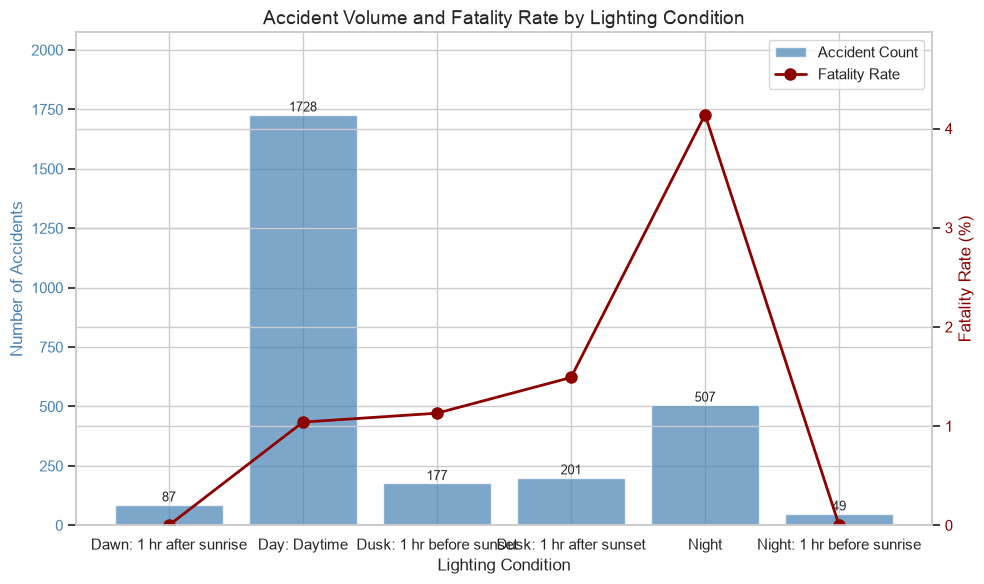

In [17]:
#4.1 Lighting Conditions: Day/Night and Dusk/Dawn Analysis

query_daynight = """

SELECT
  day_night_code,
  CASE day_night_code
    WHEN 11 THEN 'Dawn: 1 hr after sunrise'
    WHEN 12 THEN 'Day: Daytime'
    WHEN 13 THEN 'Dusk: 1 hr before sunset'
    WHEN 21 THEN 'Dusk: 1 hr after sunset'
    WHEN 22 THEN 'Night'
    WHEN 23 THEN 'Night: 1 hr before sunrise'
  END AS light_conditions,
  COUNT (*) AS accident_count,
  SUM(fatalities) AS fatalities,
  SUM(injured_persons) AS injuries,
  ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM accidents), 2) AS pct_of_all_accidents,
  ROUND(SUM(fatalities) * 100.0 / COUNT(*), 2) AS fatality_rate

FROM accidents
GROUP BY day_night_code
ORDER BY day_night_code
"""


results_daynight = conn.execute(query_daynight).fetchdf()
print("\n\n-----------------------------------------------------")
print("💥Lighting Conditions: Day/Night & Dusk/Dawn Analysis")
print("-----------------------------------------------------")
display(results_daynight)

# Visualize the results 
sns.set(style="whitegrid")
df = results_daynight.sort_values('day_night_code')
fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(df['light_conditions'], df['accident_count'], 
               color='steelblue', alpha=0.7, label='Accident Count')
ax1.set_xlabel('Lighting Condition', fontsize=12)
ax1.set_ylabel('Number of Accidents', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, df['accident_count'].max() * 1.2)

# Secondary axis for fatality rate
ax2 = ax1.twinx()
ax2.plot(df['light_conditions'], df['fatality_rate'], 
         color='darkred', marker='o', linewidth=2, markersize=8, label='Fatality Rate')
ax2.set_ylabel('Fatality Rate (%)', color='darkred', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.set_ylim(0, df['fatality_rate'].max() * 1.2)

# Add title and layout
plt.title('Accident Volume and Fatality Rate by Lighting Condition', fontsize=14)
fig.tight_layout()

# Show value labels on bars
for bar, count in zip(bars, df['accident_count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(count), ha='center', va='bottom', fontsize=9)

# Add a legend (combine both axes)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()

### ☠️ <span style="color:orange;">4.1 Key Findings: Lighting Conditiosn and Accident Severity Analysis</span>
- Daytime is when most accidents occur (1728 incidents). This corroborates with our earlier findings (refer to section "2.3 Temporal Pattern Insights" in the notebook 02_summary_analysis.ipynb)

- Night time is by far the deadliest time of the day, with a fatality rate of 4.14% (nearly 4xs the fatality rate of day time (1.04%)).

- What really stands out: night time accounts for only 18.44% of all accidents but accounts for 21 out of 44 fatalities.  That's almost 50% of all fatalities.

- Dusk also warrants attention with fatality rates of 1.13% (hour before sunset) and 1.49% (hour after sunset).

#### Possible Contributing Factors

Could the higher fatality rate during low light conditions be due to the following reasons? While the data only tells us the numbers and not the causes, possible contributing factors include:

- Poor visibility resulting in a reduced ability to judge speed and distance
- Glare from the rising and setting sun
- Drivers failing to turn on their headlights in time, reducing their visibility to other road users
- Increased animal crossings at night

Further study into these potential causes is needed to develop targeted interventions and make Okinawa's roads safer after dark.

..........  

### **4.2 Holiday Impact**  
Holidays may bring a different driver profile and traffic pattern to the roads. Let's examine the holiday itself and the eve before:
- Are holidays more deadly than regular days?  
- Do holiday accidents cluster at different hours and days of the week compared to regular days?

##### 👩🏻‍💻  *<span style="color:#0279f0">SQL: Analysing Holiday Impact on Accident Counts...</span>*



-------------------------------------------
💥Overview By Holiday Code
-------------------------------------------


,public_holiday_code,day_type,accident_count,total_fatalities,total_injured,pct_of_all_accidents,fatality_rate
0,1,Holiday,107,5.0,115.0,3.89,4.67
1,2,Holiday Eve,96,1.0,132.0,3.49,1.04
2,3,Regular Day,2546,38.0,2983.0,92.62,1.49


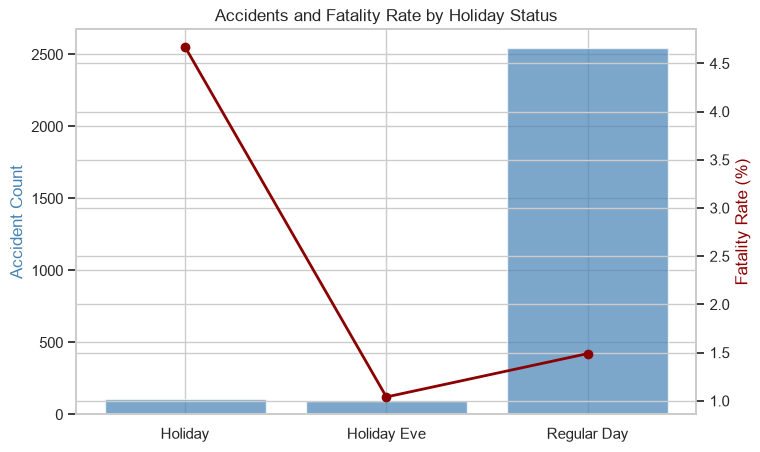



-------------------------------------------
💥Holiday Accidents & Time of Occurence
-------------------------------------------


,day_type,occurence_hour,accident_count,total_fatalities,fatality_rate
0,Holiday,0,2,0.0,0.00
1,Holiday,1,3,0.0,0.00
2,Holiday,2,1,0.0,0.00
3,Holiday,3,3,1.0,33.33
4,Holiday,4,2,0.0,0.00
...,...,...,...,...,...
64,Regular Day,19,155,1.0,0.65
65,Regular Day,20,111,2.0,1.80
66,Regular Day,21,68,2.0,2.94
67,Regular Day,22,54,2.0,3.70


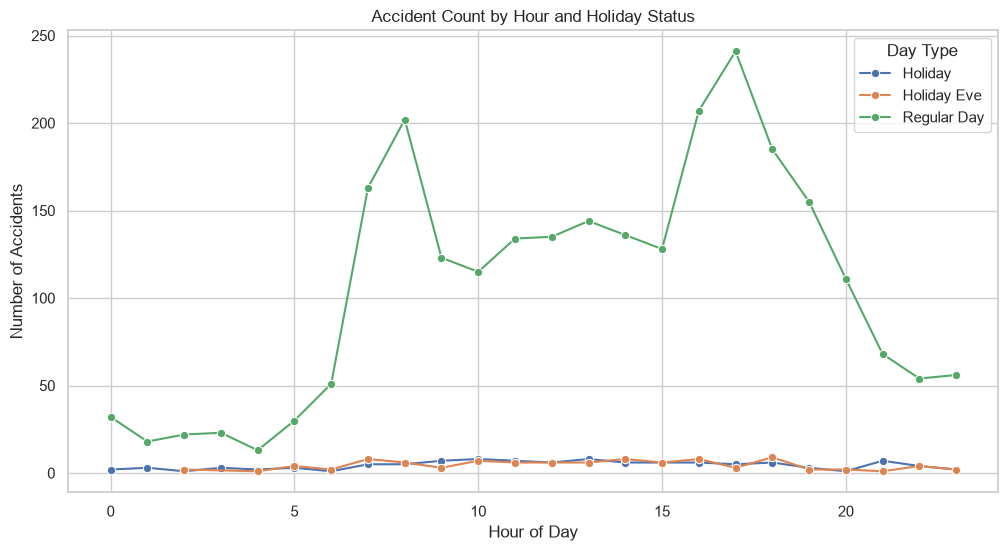



-------------------------------------------
💥Holiday Accidents by Day of Week
-------------------------------------------


,day_type,occurence_day_code,day_of_week,accident_count,total_fatalities,fatality_rate
0,Holiday,1,Sunday,28,2.0,7.14
1,Holiday,2,Monday,51,3.0,5.88
2,Holiday,4,Wednesday,8,0.0,0.00
3,Holiday,6,Friday,10,0.0,0.00
4,Holiday,7,Saturday,10,0.0,0.00
5,Holiday Eve,1,Sunday,34,0.0,0.00
6,Holiday Eve,3,Tuesday,15,0.0,0.00
7,Holiday Eve,5,Thursday,17,1.0,5.88
8,Holiday Eve,6,Friday,8,0.0,0.00
9,Holiday Eve,7,Saturday,22,0.0,0.00


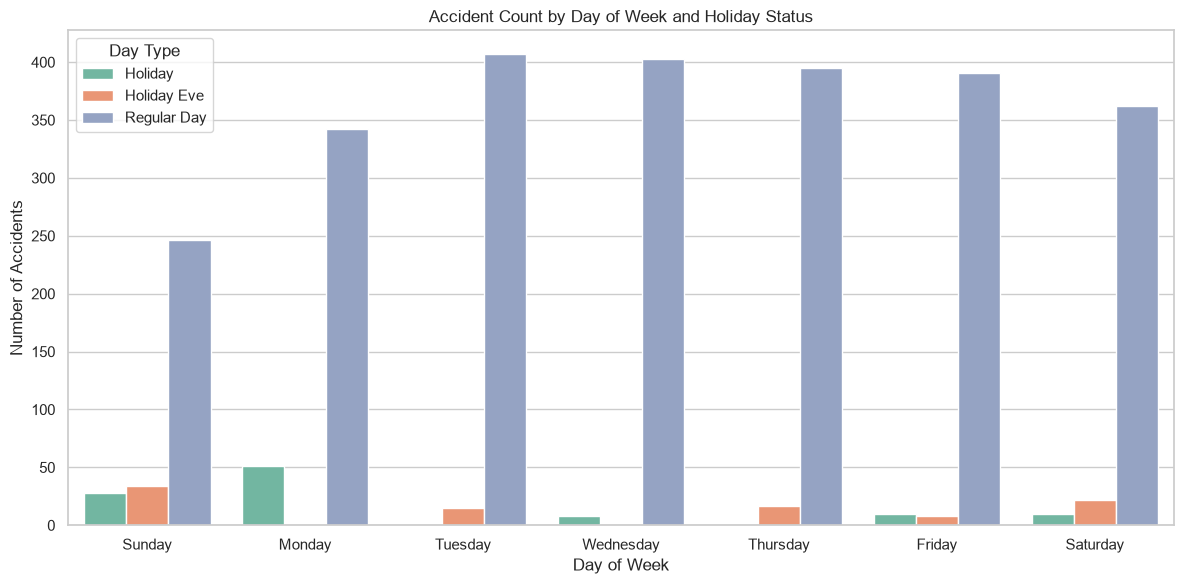

In [18]:
# 4.2 Holiday Impact
# Are holiday periods more deadly despite different traffic patterns?

#=====================================================================
# 4.2a: Overview by holiday code
#=====================================================================

query_4_2_holiday_overview = """
SELECT
    public_holiday_code,
    ['Holiday', 'Holiday Eve', 'Regular Day'][public_holiday_code] AS day_type,
    COUNT(*) AS accident_count,
    SUM(fatalities) AS total_fatalities,
    SUM(injured_persons) AS total_injured,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM accidents), 2) AS pct_of_all_accidents,
    ROUND(SUM(fatalities) * 100.0 / COUNT(*), 2) AS fatality_rate
FROM accidents
GROUP BY public_holiday_code
ORDER BY public_holiday_code
"""
results_4_2_holiday_overview = conn.execute(query_4_2_holiday_overview).fetchdf()
print("\n\n-------------------------------------------")
print("💥Overview By Holiday Code")
print("-------------------------------------------")
display(results_4_2_holiday_overview)

#visual for 4.2a
df = results_4_2_holiday_overview.sort_values('public_holiday_code')
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.bar(df['day_type'], df['accident_count'], color='steelblue', alpha=0.7, label='Accidents')
ax1.set_ylabel('Accident Count', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(df['day_type'], df['fatality_rate'], color='darkred', marker='o', linewidth=2, label='Fatality Rate %')
ax2.set_ylabel('Fatality Rate (%)', color='darkred')
plt.title('Accidents and Fatality Rate by Holiday Status')
plt.show()

#=====================================================================
# 4.2b: Holiday accidents by hour: any clustering?
#=====================================================================

query_4_2_holiday_by_hour = """
SELECT
    ['Holiday','Holiday Eve', 'Regular Day'][public_holiday_code] AS day_type,
    occurence_hour,
    COUNT(*) AS accident_count,
    SUM(fatalities) AS total_fatalities,
    ROUND(SUM(fatalities) * 100.0 / COUNT(*), 2) AS fatality_rate
FROM accidents
GROUP BY ALL
ORDER BY ALL
"""
results_4_2_holiday_by_hour = conn.execute(query_4_2_holiday_by_hour).fetchdf()
print("\n\n-------------------------------------------")
print("💥Holiday Accidents & Time of Occurence")
print("-------------------------------------------")
display(results_4_2_holiday_by_hour)

#visual for 4.2b
df_hour = results_4_2_holiday_by_hour
plt.figure(figsize=(12,6))
sns.lineplot(data=df_hour, x='occurence_hour', y='accident_count', hue='day_type', marker='o')
plt.title('Accident Count by Hour and Holiday Status')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.legend(title='Day Type')
plt.show()


#=====================================================================
# 4.2c: Holiday accidents by day of week
#=====================================================================

query_4_2_holiday_by_dow = """
SELECT
    ['Holiday', 'Holiday Eve', 'Regular Day'][public_holiday_code] AS day_type,
    occurence_day_code,
    ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'][occurence_day_code] AS day_of_week,
    COUNT(*) AS accident_count,
    SUM(fatalities) AS total_fatalities,
    ROUND(SUM(fatalities) * 100.0 / COUNT(*), 2) AS fatality_rate
FROM accidents
GROUP BY ALL
ORDER BY ALL
"""

results_4_2_holiday_by_dow = conn.execute(query_4_2_holiday_by_dow).fetchdf()
print("\n\n-------------------------------------------")
print("💥Holiday Accidents by Day of Week")
print("-------------------------------------------")
display(results_4_2_holiday_by_dow)

#visual for 4.2c
df_dow = results_4_2_holiday_by_dow.copy()

# Ensure proper order for days
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df_dow['day_of_week'] = pd.Categorical(df_dow['day_of_week'], categories=day_order, ordered=True)

plt.figure(figsize=(12,6))
sns.barplot(data=df_dow, x='day_of_week', y='accident_count', hue='day_type', palette='Set2')
plt.title('Accident Count by Day of Week and Holiday Status')
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

###<span style="color:orange;">>4.2 Key Findings: Holiday Impact on Accidents</span>
Note: The holiday classification in this dataset is based on Japanese public holidays only. US federal holidays observed by SOFA members (US military) are not captured in this analysis. However, as SOFA members make up approximately 5.5% of Okinawa's population, their impact on overall road traffic patterns is unlikely to be significant.

- There were in total 17 Japanese public holidays in 2024 with 107 accidents total, averaging about 6-7 per day vs 349 regular days averaging about 7-8 accidents per day

- Holidays accounted for only 3.89% of all accidents but had a fatality rate of 4.67%. That's more than 3x that of regular days (1.49%), even surpassing night time driving (4.14%).  

- Holiday eves are comparatively safe, with a fatality rate of 1.04%. The danger seems concentrated on the holiday itself.  

- Holiday accidents, unlike the regular day rush hour pattern, see late night and early morning hours recording the highest fatality rates.

- <span style="color:orange;">Holiday eves falling on Sundays recorded the highest accident count among all eve days (34 accidents), while Monday holidays recorded the highest count among all holiday days (51 accidents).  Could these 2 figures be linked?  
</span>

In Japan, when a public holiday falls on a Sunday, the following Monday is observed as a holiday instead. Could this be an extended weekend effect where Sunday eve activity is elevated in anticipation of the Monday holiday, resulting in higher accident counts across both days?

<span style="color:orange">*Further statistical analysis on the disproportionately high fatality rate on holidays and the potential extended weekend effect should be conducted to determine whether there is a significant correlation between holiday periods and accident severity in Okinawa.*</span>
